In [31]:
# apri una cartella DICOM e apri il file DICOM
# per visualizzarlo con pydicom e matplotlib
import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from skimage import measure

def carica_volume_dicom(cartella):
    files = [f for f in os.listdir(cartella) if f.lower().endswith('.dcm')]
    paths = [os.path.join(cartella, f) for f in files]
    datasets = [pydicom.dcmread(p) for p in paths]
    try:
        datasets.sort(key=lambda ds: float(ds.ImagePositionPatient[2]))
    except Exception:
        datasets.sort(key=lambda ds: int(ds.InstanceNumber))
    # Conversione in HU
    slices_hu = []
    for ds in datasets:
        img = ds.pixel_array.astype(np.float32)
        slope = float(ds.RescaleSlope)
        intercept = float(ds.RescaleIntercept)
        img_hu = img * slope + intercept
        slices_hu.append(img_hu)
    volume_hu = np.stack(slices_hu, axis=0)
    return volume_hu

def mostra_fette(volume, num_fette=5):
    step = max(1, volume.shape[0] // num_fette)
    for i in range(0, volume.shape[0], step):
        plt.imshow(volume[i], cmap='bone')
        plt.title(f"Slice {i}")
        plt.axis('off')
        plt.show()
        if i // step + 1 >= num_fette:
            break



In [32]:
# crea una ROI cilindrica di raggio 10 pixel e spessore 5 pixel centrata in [50,50, 38]
def crea_roi_cilindrica(volume, centro, raggio, spessore):
    """
    Crea una maschera cilindrica in un volume 3D.
    centro: [z, y, x] (int)
    raggio: raggio del cilindro (int)
    spessore: numero di slice lungo z (int, deve essere dispari per simmetria)
    """
    num_z, num_y, num_x = volume.shape
    zz, yy, xx = np.ogrid[:num_z, :num_y, :num_x]
    mask = (
        (xx - centro[2])**2 + (yy - centro[1])**2 <= raggio**2
    ) & (
        np.abs(zz - centro[0]) <= spessore // 2
    )
    return mask

# plotta il bordo della ROI sopra la fetta centrale 
def mostra_roi_sovrapposta(volume, mask, z):
    plt.imshow(volume[z], cmap='bone')
    # Trova i contorni della ROI
    contours = measure.find_contours(mask[z], 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='blue', linewidth=2)
    plt.title(f"ROI sovrapposta alla slice z={z}")
    plt.axis('off')
    plt.show()

# mostra ROI sovrapposta con zoom attorno al centro della ROI



    

# plotta solo la ROI
def mostra_solo_roi(volume, mask, z):
    plt.imshow(volume[z] * mask[z], cmap='gray')
    plt.title(f"ROI cilindrica - slice z={z}")
    plt.axis('off')
    plt.show()

def mostra_bordo_proiezione_laterale(volume, mask, num_slices=30):
    """
    Mostra solo il bordo della ROI sulla proiezione laterale (z-y),
    considerando solo num_slices slice attorno a quella centrale.
    """
    z_centro = volume.shape[0] // 2
    half = num_slices // 2
    z_start = max(0, z_centro - half)
    z_end = min(volume.shape[0], z_centro + half)

    # Proiezione massima lungo x, solo sulle slice selezionate
    proiezione_volume = np.max(volume[z_start:z_end], axis=2)
    proiezione_mask = np.max(mask[z_start:z_end], axis=2)

    plt.imshow(proiezione_volume, cmap='bone')

    # Trova i contorni della ROI proiettata
    contours = measure.find_contours(proiezione_mask, 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='blue', linewidth=2)

    plt.title(f"Bordo ROI sulla proiezione laterale (z-y), slice {z_start}:{z_end}")
    plt.axis('off')
    plt.show()

In [33]:
#Fai istogramma dei valori contenuti nella ROI
def calcola_histogram(volume, roi=None, roi_name=None):
    """
    Restituisce hist, bin_edges dell'istogramma dei valori del volume (o della ROI).
    """
    if roi is not None:
        mask = np.zeros(volume.shape, dtype=bool)
        mask[roi] = True
        data = volume[mask]
    else:
        data = volume.flatten()
    
    num_bins = int(np.sqrt(data.size))
    hist, bin_edges = np.histogram(data, bins=num_bins)

    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='blue', alpha=0.7)
    plt.title(f'Histogram of {roi_name}')
    plt.xlabel('Pixel Value')
    plt.ylabel('Count')
    plt.grid()
    plt.show()
    return hist, bin_edges


In [34]:
def mostra_crop_con_maschera(volume, mask, z, margin=20):
    """
    Mostra una versione croppata della slice z con la maschera sovrapposta.
    Il crop è centrato sulla maschera, con un margine opzionale.
    """
    # Trova i bounding box della maschera sulla slice z
    coords = np.argwhere(mask[z])
    if coords.size == 0:
        print("Maschera vuota nella slice selezionata.")
        return
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    # Applica margine e limiti
    y_min = max(y_min - margin, 0)
    y_max = min(y_max + margin, volume.shape[1])
    x_min = max(x_min - margin, 0)
    x_max = min(x_max + margin, volume.shape[2])

    # Croppa immagine e maschera
    img_crop = volume[z, y_min:y_max, x_min:x_max]
    mask_crop = mask[z, y_min:y_max, x_min:x_max]

    plt.imshow(img_crop, cmap='bone')
    contours = measure.find_contours(mask_crop, 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='red', linewidth=2)
    plt.title(f"Crop slice {z} con maschera sovrapposta")
    plt.colorbar()
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()


def mostra_crop_laterale_con_maschera(volume, mask, margin=10):
    """
    Mostra la proiezione laterale (z-y) croppata attorno alla maschera,
    con il bordo della maschera sovrapposto.
    """
    # Proiezione massima lungo x (z-y)
    proiezione_volume = np.max(volume, axis=2)
    proiezione_mask = np.max(mask, axis=2)

    # Trova bounding box della maschera proiettata
    coords = np.argwhere(proiezione_mask)
    if coords.size == 0:
        print("Maschera vuota nella proiezione.")
        return
    z_min, y_min = coords.min(axis=0)
    z_max, y_max = coords.max(axis=0)
    z_min = max(z_min - margin, 0)
    z_max = min(z_max + margin, volume.shape[0])
    y_min = max(y_min - margin, 0)
    y_max = min(y_max + margin, volume.shape[1])

    # Croppa proiezione e maschera
    img_crop = proiezione_volume[z_min:z_max, y_min:y_max]
    mask_crop = proiezione_mask[z_min:z_max, y_min:y_max]

    plt.imshow(img_crop, cmap='bone')
    contours = measure.find_contours(mask_crop, 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='red', linewidth=2)
    plt.title("Crop proiezione laterale (z-y) con maschera")
    plt.xlabel('Y-axis')
    plt.ylabel('Z-axis')
    plt.colorbar()
    plt.show()

In [35]:
# Calcolare alcune metrice degli istogrammi: media, mediana, varianza, deviazione_standard, skewness, kurtosis
def calcola_metriche_istogramma(hist, bin_edges):
    """
    Calcola e restituisce le metriche dell'istogramma: media, mediana, varianza, skewness, kurtosis.
    """
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total_count = hist.sum()
    
    # Media
    mean = np.sum(hist * bin_centers) / total_count
    
    # Mediana
    cumulative_hist = np.cumsum(hist)
    median_index = np.searchsorted(cumulative_hist, total_count / 2)
    median = bin_centers[median_index]
    
    # Varianza
    variance = np.sum(hist * (bin_centers - mean)**2) / total_count

    # Deviazione standard
    std_dev = np.sqrt(variance)
    
    # Skewness
    skewness = np.sum(hist * (bin_centers - mean)**3) / (total_count * variance**1.5)
    
    # Kurtosis
    kurtosis = np.sum(hist * (bin_centers - mean)**4) / (total_count * variance**2) - 3
    
    return mean, median, variance, std_dev, skewness, kurtosis

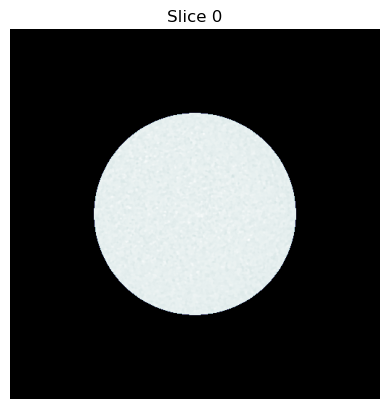

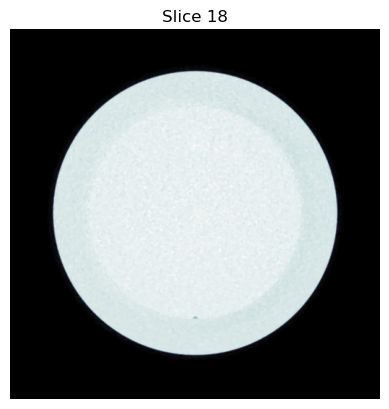

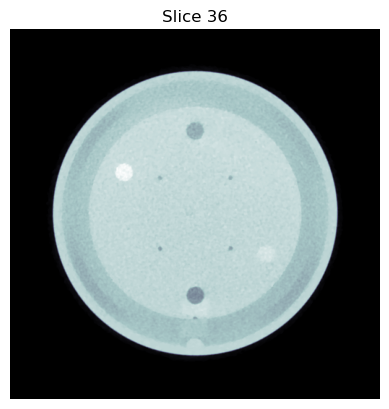

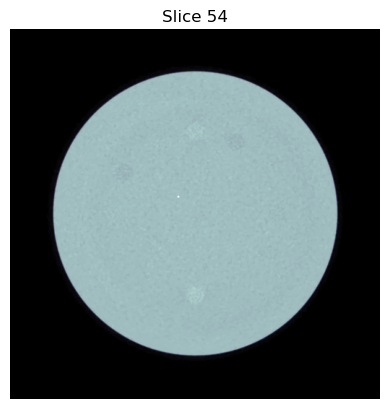

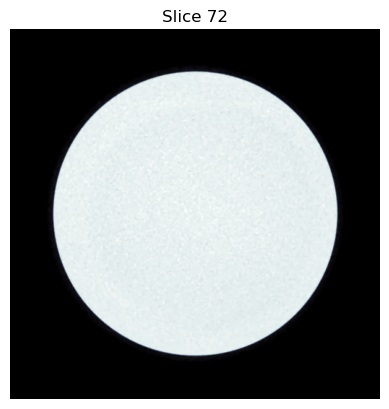

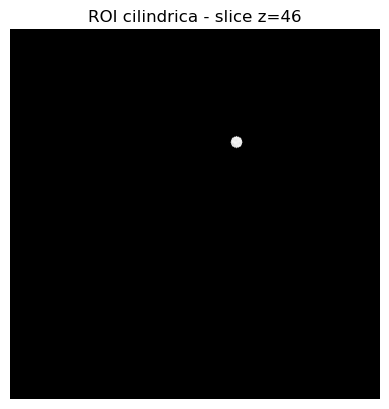

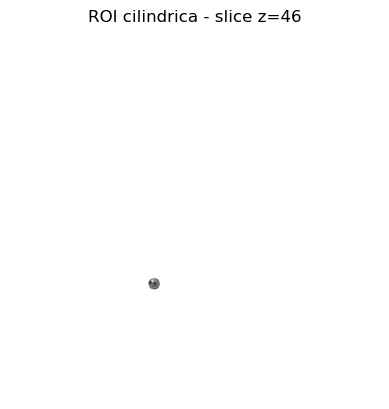

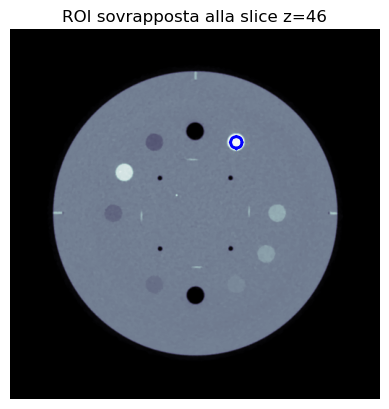

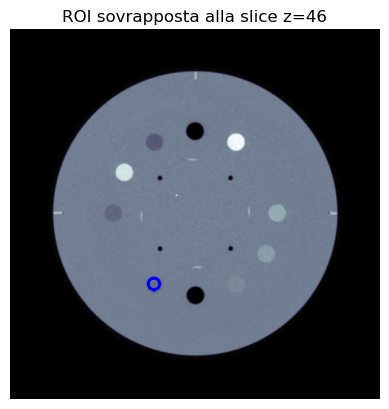

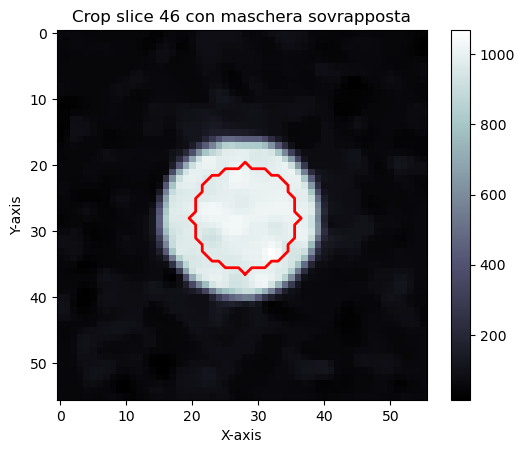

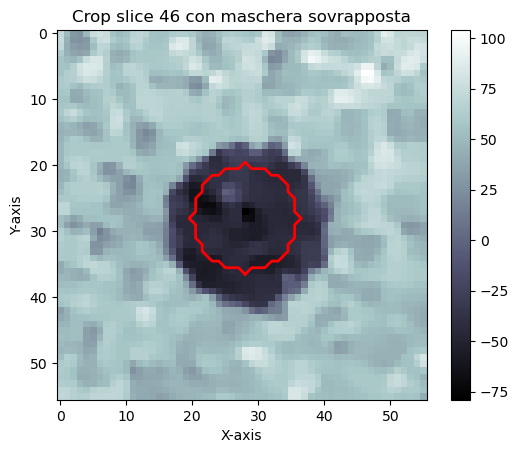

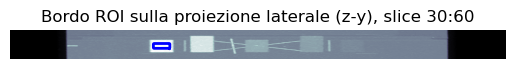

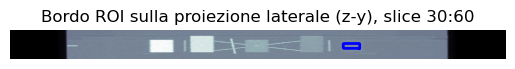

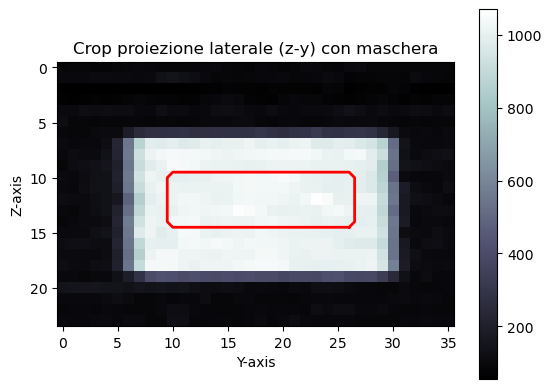

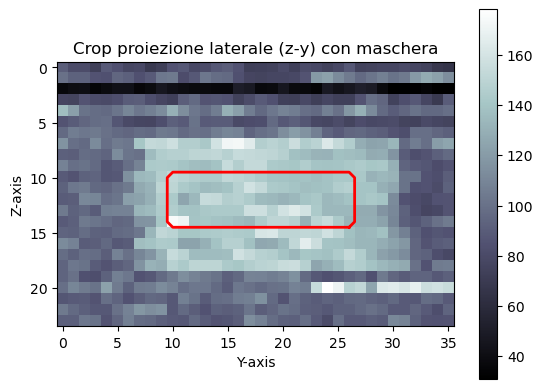

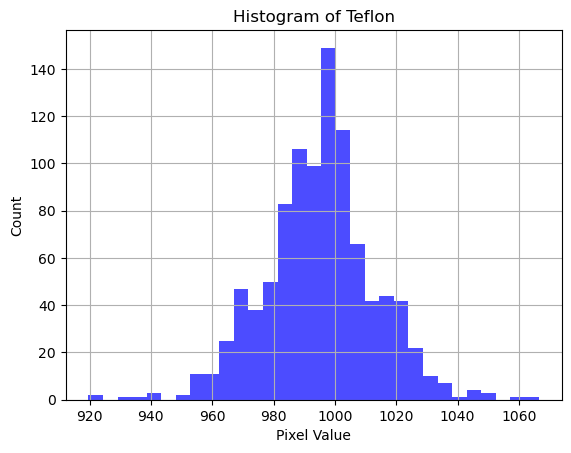

[  2   0   1   1   3   0   2  11  11  25  47  38  50  83 106  99 149 114
  66  42  44  42  22  10   7   1   4   3   0   1   1]
[ 922.       926.74194  931.4839   936.2258   940.9677   945.70966
  950.4516   955.19354  959.9355   964.6774   969.4194   974.1613
  978.9032   983.64514  988.3871   993.129    997.871   1002.6129
 1007.35486 1012.0968  1016.8387  1021.5806  1026.3226  1031.0646
 1035.8064  1040.5483  1045.2903  1050.0322  1054.7742  1059.5161
 1064.258   1069.     ]


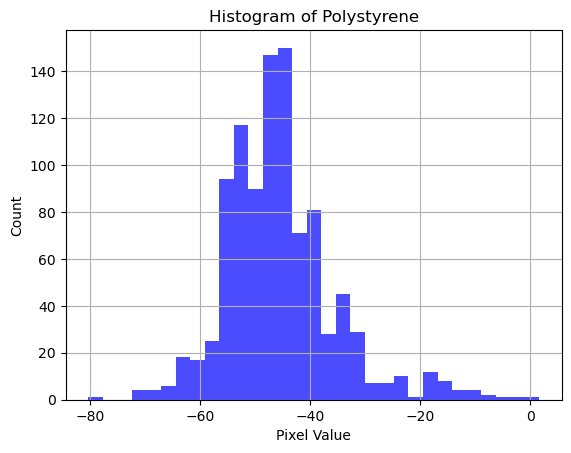

[  1   0   0   4   4   6  18  17  25  94 117  90 147 150  71  81  28  45
  29   7   7  10   1  12   8   4   4   2   1   1   1]
[-79.        -76.354836  -73.70968   -71.064514  -68.41936   -65.77419
 -63.129032  -60.48387   -57.83871   -55.19355   -52.548386  -49.903225
 -47.258064  -44.612904  -41.967743  -39.322582  -36.677418  -34.032257
 -31.387096  -28.741936  -26.096775  -23.451612  -20.806452  -18.161291
 -15.5161295 -12.870968  -10.225806   -7.580645   -4.935484   -2.2903225
   0.3548387   3.       ]
Metrics for Teflon: Mean=997.43, Median=1000.24, Variance=322.88, Std Dev=17.97, Skewness=-0.06, Kurtosis=0.97
Metrics for Polystyrene: Mean=-44.20, Median=-45.94, Variance=101.82, Std Dev=10.09, Skewness=0.98, Kurtosis=2.35


In [ ]:
if __name__ == "__main__":
    volume = carica_volume_dicom("../Cone-Beam CT/Image_quality/Protocolli CBCT 31_05_2025/Testa catphan/iCBCT/QA_SNCmachine_TBHD")
    mostra_fette(volume, num_fette=5)


    #Centri Catphan
    #centro_Tef = [37, 156, 313]  # esempio: z=50, y=100, x=100
    #centro_Poly = [37, 352, 199]  # esempio: z=50, y=100, x=100

    centro_Tef = [46, 156, 313]  # esempio: z=50, y=100, x=100
    centro_Poly = [46, 352, 199]  # esempio: z=50, y=100, x=100
    
    raggio = 8
    spessore = 5
    
    mask_Tef = crea_roi_cilindrica(volume, centro_Tef, raggio, spessore)
    mask_Poly = crea_roi_cilindrica(volume, centro_Poly, raggio, spessore)

    # Visualizza la ROI da sola sulla slice centrale del cilindro
    mostra_solo_roi(volume, mask_Tef, centro_Tef[0])
    mostra_solo_roi(volume, mask_Poly, centro_Poly[0])

    # Visualizza la ROI sovrapposta alla slice centrale
    mostra_roi_sovrapposta(volume, mask_Tef, centro_Tef[0])
    mostra_roi_sovrapposta(volume, mask_Poly, centro_Poly[0])

    mostra_crop_con_maschera(volume, mask_Tef, z=centro_Tef[0])
    mostra_crop_con_maschera(volume, mask_Poly, z=centro_Poly[0])

    mostra_bordo_proiezione_laterale(volume, mask_Tef, num_slices=30)
    mostra_bordo_proiezione_laterale(volume, mask_Poly, num_slices=30)

    mostra_crop_laterale_con_maschera(volume, mask_Tef, margin=10)
    mostra_crop_laterale_con_maschera(volume, mask_Poly, margin=10)

    hist_Tef, bin_edges_Tef = calcola_histogram(volume, mask_Tef, roi_name='Teflon')
    print(hist_Tef)
    print(bin_edges_Tef)
    hist_Poly, bin_edges_Poly = calcola_histogram(volume, mask_Poly, roi_name='Polystyrene')
    print(hist_Poly)
    print(bin_edges_Poly)

    # Calcola e stampa le metriche degli istogrammi
    metrics_Tef = calcola_metriche_istogramma(hist_Tef, bin_edges_Tef)
    metrics_Poly = calcola_metriche_istogramma(hist_Poly, bin_edges_Poly)
    print(f"Metrics for Teflon: Mean={metrics_Tef[0]:.2f}, Median={metrics_Tef[1]:.2f}, Variance={metrics_Tef[2]:.2f}, Std Dev={metrics_Tef[3]:.2f}, Skewness={metrics_Tef[4]:.2f}, Kurtosis={metrics_Tef[5]:.2f}")
    print(f"Metrics for Polystyrene: Mean={metrics_Poly[0]:.2f}, Median={metrics_Poly[1]:.2f}, Variance={metrics_Poly[2]:.2f}, Std Dev={metrics_Poly[3]:.2f}, Skewness={metrics_Poly[4]:.2f}, Kurtosis={metrics_Poly[5]:.2f}")
    